In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('male_players.csv',low_memory=False)

In [3]:
df.shape

(180021, 109)

In [4]:
df.head()

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,...,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,19+3
4,165153,/player/165153/karim-benzema/240002,24.0,2.0,2023-09-22,K. Benzema,Karim Benzema,"CF, ST",90,90,...,64+3,64+3,64+3,64+3,60+3,55+3,55+3,55+3,60+3,18+3


In [5]:
selected_columns = [
    'player_id', 'short_name', 'age', 'height_cm', 'weight_kg', 
    'nationality_name', 'club_name', 'league_name', 'overall', 'potential', 
    'value_eur', 'wage_eur', 'player_positions', 'pace', 'shooting', 
    'passing', 'dribbling', 'defending', 'physic'
]

In [6]:
filtered_df = df[selected_columns]

In [7]:
filtered_df.shape

(180021, 19)

In [8]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180021 entries, 0 to 180020
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   player_id         180021 non-null  int64  
 1   short_name        180021 non-null  object 
 2   age               180021 non-null  int64  
 3   height_cm         180021 non-null  int64  
 4   weight_kg         180021 non-null  int64  
 5   nationality_name  180021 non-null  object 
 6   club_name         178156 non-null  object 
 7   league_name       178156 non-null  object 
 8   overall           180021 non-null  int64  
 9   potential         180021 non-null  int64  
 10  value_eur         177868 non-null  float64
 11  wage_eur          178173 non-null  float64
 12  player_positions  180021 non-null  object 
 13  pace              159997 non-null  float64
 14  shooting          159997 non-null  float64
 15  passing           159997 non-null  float64
 16  dribbling         15

In [9]:
filtered_df = filtered_df.dropna(subset=['value_eur','wage_eur'])

In [10]:
(filtered_df[['value_eur', 'wage_eur']].isnull().sum())

value_eur    0
wage_eur     0
dtype: int64

In [11]:
filtered_df['maaliyet_per_overall'] = filtered_df['value_eur'] / filtered_df['overall']

In [12]:
filtered_df.head()

,player_id,short_name,age,height_cm,weight_kg,nationality_name,club_name,league_name,overall,potential,value_eur,wage_eur,player_positions,pace,shooting,passing,dribbling,defending,physic,maaliyet_per_overall
0,231747,K. Mbappé,24,182,75,France,Paris Saint Germain,Ligue 1,91,94,181500000.0,230000.0,"ST, LW",97.0,90.0,80.0,92.0,36.0,78.0,1.994505e+06
1,239085,E. Haaland,22,195,94,Norway,Manchester City,Premier League,91,94,185000000.0,340000.0,ST,89.0,93.0,66.0,80.0,45.0,88.0,2.032967e+06
2,192985,K. De Bruyne,32,181,75,Belgium,Manchester City,Premier League,91,91,103000000.0,350000.0,"CM, CAM",72.0,88.0,94.0,87.0,65.0,78.0,1.131868e+06
3,158023,L. Messi,36,169,67,Argentina,Inter Miami,Major League Soccer,90,90,41000000.0,23000.0,"CF, CAM",80.0,87.0,90.0,94.0,33.0,64.0,4.555556e+05
4,165153,K. Benzema,35,185,81,France,Al Ittihad,Pro League,90,90,51000000.0,95000.0,"CF, ST",79.0,88.0,83.0,87.0,39.0,78.0,5.666667e+05


In [13]:
young_talents = filtered_df[(filtered_df['age'] <= 23 ) & (filtered_df['overall'] >= 75)]

In [14]:
young_talents.head()

,player_id,short_name,age,height_cm,weight_kg,nationality_name,club_name,league_name,overall,potential,value_eur,wage_eur,player_positions,pace,shooting,passing,dribbling,defending,physic,maaliyet_per_overall
1,239085,E. Haaland,22,195,94,Norway,Manchester City,Premier League,91,94,185000000.0,340000.0,ST,89.0,93.0,66.0,80.0,45.0,88.0,2.032967e+06
8,238794,Vini Jr.,22,176,73,Brazil,Real Madrid,La Liga,89,94,158500000.0,310000.0,LW,95.0,82.0,78.0,90.0,29.0,68.0,1.780899e+06
35,256790,J. Musiala,20,184,72,Germany,FC Bayern München,Bundesliga,86,93,134500000.0,79000.0,"CAM, CM, LM",85.0,75.0,76.0,91.0,63.0,61.0,1.563953e+06
36,247635,K. Kvaratskhelia,22,183,70,Georgia,Napoli,Serie A,86,92,109000000.0,95000.0,"LW, RW",84.0,80.0,81.0,87.0,41.0,71.0,1.267442e+06
37,251854,Pedri,20,174,60,Spain,FC Barcelona,La Liga,86,92,105000000.0,165000.0,CM,78.0,69.0,82.0,88.0,70.0,74.0,1.220930e+06


In [15]:
cheap_stars = young_talents.sort_values(by='maaliyet_per_overall', ascending=True)

In [16]:
cheap_stars.head()

,player_id,short_name,age,height_cm,weight_kg,nationality_name,club_name,league_name,overall,potential,value_eur,wage_eur,player_positions,pace,shooting,passing,dribbling,defending,physic,maaliyet_per_overall
164731,205988,L. Shaw,18,185,75,England,Manchester United,Premier League,75,86,2100000.0,30000.0,LB,82.0,39.0,68.0,76.0,75.0,73.0,28000.000000
164785,201455,G. Kondogbia,21,188,80,France,Monaco,Ligue 1,75,80,2300000.0,30000.0,"CDM, CM",66.0,55.0,70.0,68.0,71.0,84.0,30666.666667
164745,210047,F. Schär,22,186,85,Switzerland,Basel,Super League,75,83,2500000.0,50000.0,CB,78.0,68.0,70.0,64.0,73.0,82.0,33333.333333
164754,213899,É. Balanta,21,181,79,Colombia,River Plate,Liga Profesional,75,82,2500000.0,50000.0,CB,75.0,39.0,52.0,65.0,75.0,83.0,33333.333333
164764,203030,R. Knoche,22,190,77,Germany,VfL Wolfsburg,Bundesliga,75,81,2500000.0,40000.0,CB,68.0,42.0,50.0,54.0,77.0,71.0,33333.333333


In [17]:
print(cheap_stars[['short_name', 'age', 'overall', 'potential', 'value_eur']].head(10))

             short_name  age  overall  potential  value_eur
164731          L. Shaw   18       75         86  2100000.0
164785     G. Kondogbia   21       75         80  2300000.0
164745         F. Schär   22       75         83  2500000.0
164754       É. Balanta   21       75         82  2500000.0
164764        R. Knoche   22       75         81  2500000.0
164813         A. Mandi   22       75         79  2500000.0
164788       J. Veltman   22       75         80  2500000.0
164761  B. Martins Indi   22       75         81  2500000.0
164814      V. van Dijk   22       75         79  2500000.0
164839  Diogo Figueiras   22       75         78  2500000.0


In [18]:
filtered_df = df[df['fifa_version'] == 24.0].copy()
secilen_sutunlar = [
    'player_id', 'short_name', 'age', 'height_cm', 'weight_kg', 
    'nationality_name', 'club_name', 'league_name', 'overall', 'potential', 
    'value_eur', 'wage_eur', 'player_positions', 'pace', 'shooting', 
    'passing', 'dribbling', 'defending', 'physic'
]
filtered_df = filtered_df[secilen_sutunlar]
filtered_df = filtered_df.dropna(subset=['value_eur', 'wage_eur'])
filtered_df['maliyet_per_overall'] = filtered_df['value_eur'] / filtered_df['overall']
print("Güncel ve temizlenmiş FC 24 oyuncu sayısı:", filtered_df.shape[0])


Güncel ve temizlenmiş FC 24 oyuncu sayısı: 18250


In [19]:
filtered_df.head()

,player_id,short_name,age,height_cm,weight_kg,nationality_name,club_name,league_name,overall,potential,value_eur,wage_eur,player_positions,pace,shooting,passing,dribbling,defending,physic,maliyet_per_overall
0,231747,K. Mbappé,24,182,75,France,Paris Saint Germain,Ligue 1,91,94,181500000.0,230000.0,"ST, LW",97.0,90.0,80.0,92.0,36.0,78.0,1.994505e+06
1,239085,E. Haaland,22,195,94,Norway,Manchester City,Premier League,91,94,185000000.0,340000.0,ST,89.0,93.0,66.0,80.0,45.0,88.0,2.032967e+06
2,192985,K. De Bruyne,32,181,75,Belgium,Manchester City,Premier League,91,91,103000000.0,350000.0,"CM, CAM",72.0,88.0,94.0,87.0,65.0,78.0,1.131868e+06
3,158023,L. Messi,36,169,67,Argentina,Inter Miami,Major League Soccer,90,90,41000000.0,23000.0,"CF, CAM",80.0,87.0,90.0,94.0,33.0,64.0,4.555556e+05
4,165153,K. Benzema,35,185,81,France,Al Ittihad,Pro League,90,90,51000000.0,95000.0,"CF, ST",79.0,88.0,83.0,87.0,39.0,78.0,5.666667e+05


In [20]:
young_talents = filtered_df[(filtered_df['age'] <= 23 ) & (filtered_df['overall'] >= 75)]

In [21]:
cheap_stars = young_talents.sort_values(by='maliyet_per_overall', ascending=True)

In [22]:
print(cheap_stars[['short_name', 'age', 'overall', 'potential', 'club_name', 'value_eur']].head(5))

           short_name  age  overall  potential          club_name  value_eur
1516      M. Kumbulla   23       75         79               Roma  7000000.0
1380  Rafael Cachoira   23       76         76         Bragantino  7500000.0
1517         A. Flips   23       75         79         Anderlecht  8000000.0
1480     R. Sessegnon   23       75         80  Tottenham Hotspur  8000000.0
1461         O. Kabak   23       75         81     TSG Hoffenheim  8000000.0


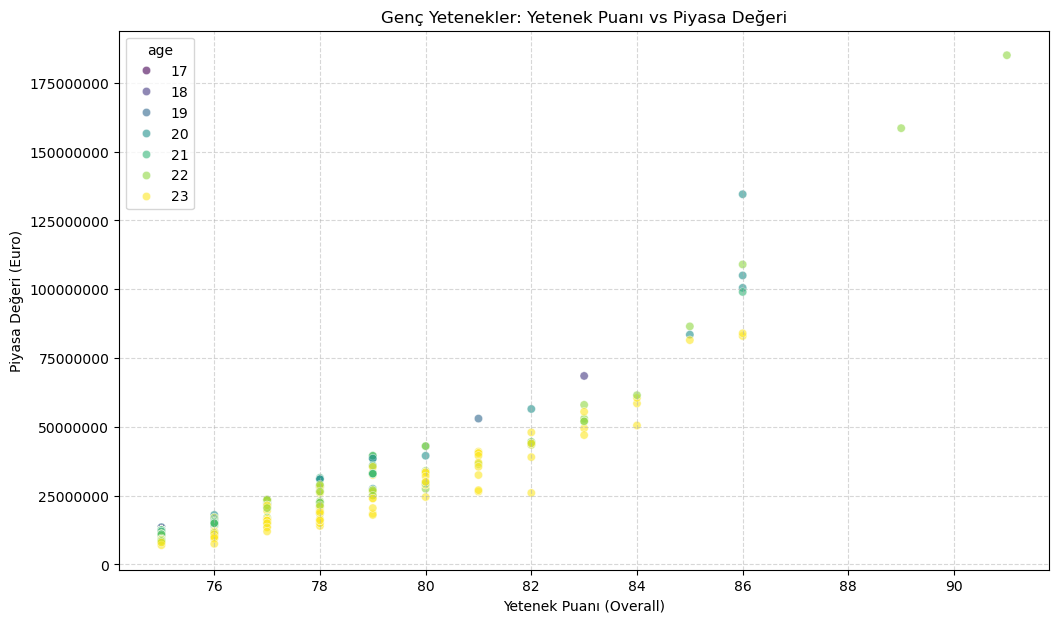

In [23]:

plt.figure(figsize=(12, 7))

# genc_yetenekler DataFrame'ini kullanıyoruz
# alpha=0.6 noktaları biraz şeffaf yapar ki üst üste binenleri görebilelim
sns.scatterplot(data=young_talents, x='overall', y='value_eur', hue='age', palette='viridis', alpha=0.6)

plt.title('Genç Yetenekler: Yetenek Puanı vs Piyasa Değeri')
plt.xlabel('Yetenek Puanı (Overall)')
plt.ylabel('Piyasa Değeri (Euro)')

# Bilimsel gösterimi (1e7 gibi) kapatmak için:
plt.ticklabel_format(style='plain', axis='y')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [24]:
filtered_df['home_position'] = filtered_df['player_positions'].str.split(',').str[0]
print(filtered_df[['short_name', 'player_positions', 'home_position']].head(10))

       short_name player_positions home_position
0       K. Mbappé           ST, LW            ST
1      E. Haaland               ST            ST
2    K. De Bruyne          CM, CAM            CM
3        L. Messi          CF, CAM            CF
4      K. Benzema           CF, ST            CF
5  R. Lewandowski               ST            ST
6     T. Courtois               GK            GK
7         H. Kane               ST            ST
8        Vini Jr.               LW            LW
9         Alisson               GK            GK


In [25]:
filtered_df['home_position'] = filtered_df['home_position'].str.strip() # Başındaki ve sonundaki görünmez boşlukları temizliyoruz

In [26]:
def categorize_by_position(position):
    if position in ['ST','CF','RW','LW']:
        return 'Attack'
    elif position in ['CAM','CM','CDM','RM','LM']:
        return 'Midfield'
    elif position in ['CB','RB','LB','LWB','RWB']:
        return 'Defender'
    elif position == 'GK':
        return 'Goalkeeper'
    else:
        return 'Unknown'

In [27]:
filtered_df['general_position'] = filtered_df['home_position'].apply(categorize_by_position)

In [28]:
print(filtered_df['general_position'].value_counts())

general_position
Midfield      6636
Defender      6143
Attack        3438
Goalkeeper    2033
Name: count, dtype: int64


In [29]:
filtered_df.head()

,player_id,short_name,age,height_cm,weight_kg,nationality_name,club_name,league_name,overall,potential,...,player_positions,pace,shooting,passing,dribbling,defending,physic,maliyet_per_overall,home_position,general_position
0,231747,K. Mbappé,24,182,75,France,Paris Saint Germain,Ligue 1,91,94,...,"ST, LW",97.0,90.0,80.0,92.0,36.0,78.0,1.994505e+06,ST,Attack
1,239085,E. Haaland,22,195,94,Norway,Manchester City,Premier League,91,94,...,ST,89.0,93.0,66.0,80.0,45.0,88.0,2.032967e+06,ST,Attack
2,192985,K. De Bruyne,32,181,75,Belgium,Manchester City,Premier League,91,91,...,"CM, CAM",72.0,88.0,94.0,87.0,65.0,78.0,1.131868e+06,CM,Midfield
3,158023,L. Messi,36,169,67,Argentina,Inter Miami,Major League Soccer,90,90,...,"CF, CAM",80.0,87.0,90.0,94.0,33.0,64.0,4.555556e+05,CF,Attack
4,165153,K. Benzema,35,185,81,France,Al Ittihad,Pro League,90,90,...,"CF, ST",79.0,88.0,83.0,87.0,39.0,78.0,5.666667e+05,CF,Attack


In [30]:
hedef_ligler = ['Ligue 1','Premier League','La Liga','Serie A','Bundesliga']
Top_5_League = filtered_df[(filtered_df['league_name'].isin(hedef_ligler))]
#Top5 ligdeki oyuncuları filtreledik.

In [31]:
Top_5_League['league_name'].unique()

array(['Ligue 1', 'Premier League', 'La Liga', 'Bundesliga', 'Serie A'],
      dtype=object)

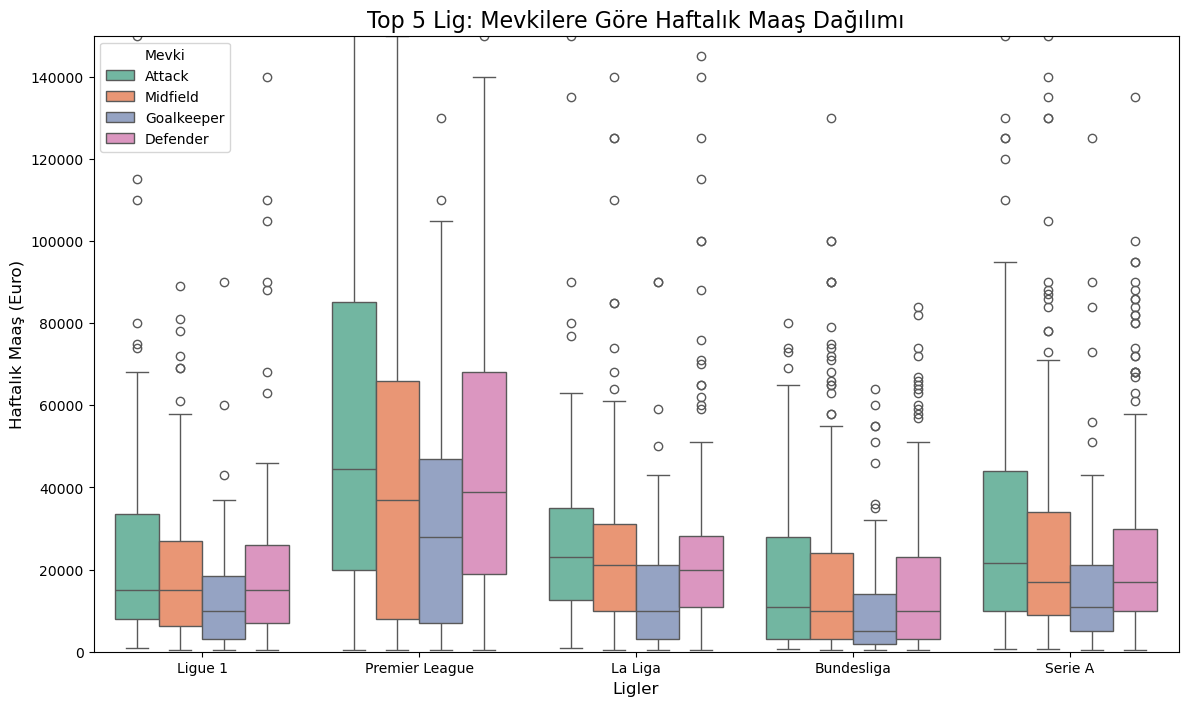

In [32]:
# Top5 lig için BoxPlot
plt.figure(figsize=(14, 8))
sns.boxplot(data=Top_5_League, x='league_name', y='wage_eur', hue='general_position', palette='Set2')
plt.title('Top 5 Lig: Mevkilere Göre Haftalık Maaş Dağılımı', fontsize=16)
plt.xlabel('Ligler', fontsize=12)
plt.ylabel('Haftalık Maaş (Euro)', fontsize=12)
plt.ylim(0, 150000) #>> Maaşları limitler.
plt.legend(title='Mevki')

plt.show()

In [33]:
# Oyuncunun çevik ya da hantal olduğunu anlayabilmek için VKI(BMI) sütununu filtered_df içerisine ekliyoruz.
filtered_df['bmi'] = filtered_df['weight_kg'] / ((filtered_df['height_cm'] / 100)**2)
print(filtered_df[['short_name','weight_kg','height_cm','bmi']].head())

     short_name  weight_kg  height_cm        bmi
0     K. Mbappé         75        182  22.642193
1    E. Haaland         94        195  24.720579
2  K. De Bruyne         75        181  22.893074
3      L. Messi         67        169  23.458562
4    K. Benzema         81        185  23.666910


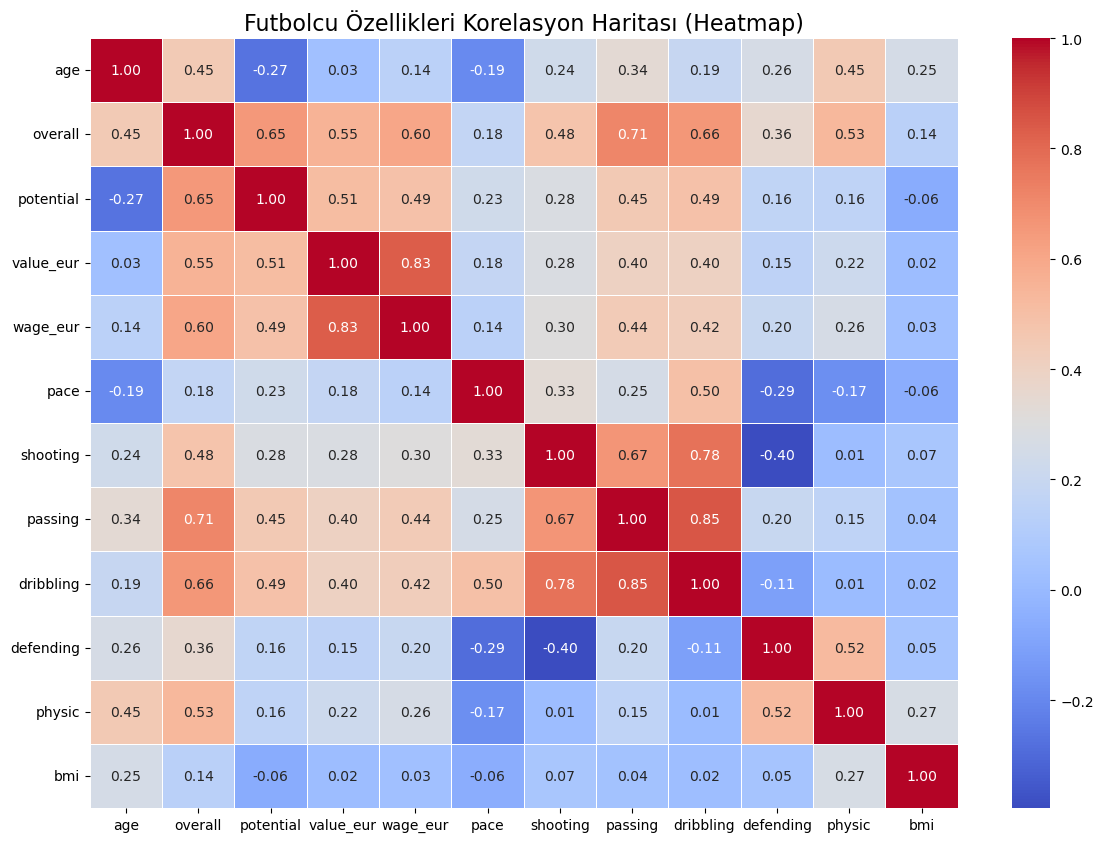

In [34]:
#HeatMap
analiz_sutunlari = [
    'age', 'overall', 'potential', 'value_eur', 'wage_eur', 
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'bmi'
]
korelasyon_matrisi = filtered_df[analiz_sutunlari].corr()
plt.figure(figsize=(14,10))
# annot=True: Kutuların içine matematiksel oranları (0.85 gibi) yazdırır.
# cmap='coolwarm': Renk paleti. Kırmızıya gittikçe ilişki güçlenir, maviye gittikçe zıtlaşır.
# fmt='.2f': Virgülden sonra sadece 2 basamak göster (Görüntü kirliliğini önler).
sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Futbolcu Özellikleri Korelasyon Haritası (Heatmap)', fontsize=16)
plt.show()


Çoklu Regresyon

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [36]:
secilen_ozellikler = ['age', 'overall', 'potential', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'bmi', 'value_eur']

In [37]:
model_df = filtered_df[secilen_ozellikler].dropna()

In [38]:
X = model_df.drop('value_eur',axis=1)
y = model_df['value_eur']

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
model = LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [42]:
y_pred = model.predict(X_test_scaled)

In [43]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [44]:
print(f"RMSE (Ortalama Sapma): {rmse:,.0f} Euro")
print(f"R2 Skoru: {r2:.4f}")

RMSE (Ortalama Sapma): 6,931,283 Euro
R2 Skoru: 0.3602


In [45]:
from sklearn.preprocessing import PolynomialFeatures

Polinom Regresyon

In [46]:
poly_converter = PolynomialFeatures(degree=2,include_bias=False)

In [47]:
X_train_poly = poly_converter.fit_transform(X_train_scaled)
X_test_poly = poly_converter.transform(X_test_scaled)

In [48]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly,y_train)

LinearRegression()

In [49]:
y_pred_poly = poly_model.predict(X_test_poly)

In [50]:
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

In [51]:
print("--- POLİNOM REGRESYON (DERECE 2) KARNESİ ---")
print(f"Eski Çoklu Regresyon RMSE : 6,931,283 Euro")
print(f"YENİ Polinom RMSE        : {rmse_poly:,.0f} Euro")
print("-" * 42)
print(f"Eski Çoklu Regresyon R2  : 0.3602")
print(f"YENİ Polinom R2          : {r2_poly:.4f}")

--- POLİNOM REGRESYON (DERECE 2) KARNESİ ---
Eski Çoklu Regresyon RMSE : 6,931,283 Euro
YENİ Polinom RMSE        : 4,120,053 Euro
------------------------------------------
Eski Çoklu Regresyon R2  : 0.3602
YENİ Polinom R2          : 0.7740


In [64]:
def poly_regression(degree):
    poly_features = PolynomialFeatures(degree=degree)
    lin_reg = LinearRegression()
    scaler=StandardScaler()
    pipeline = Pipeline([('standart_scaler',scaler),('poly_features',poly_features),('lin_reg',lin_reg)])
    pipeline.fit(X_train,y_train)
    score = pipeline.score(X_test,y_test)
    print('Skor:%',score * 100)

In [65]:
poly_regression(2)
poly_regression(3)
poly_regression(4)

Skor:% 77.39542789979869
Skor:% 96.25993625335474
Skor:% 99.02133072541392
